# Leather Manufacturing & Export — Exploratory Data Analysis

**Data Analytics Internship Project | A.S. Solutions, Tamil Nadu, India**

---

This notebook analyses the operations of a leather manufacturing & export
business that produces from **Ambur, Vaniyambadi, Ranipet and Chennai** and
exports to markets such as Italy, Germany, France, the UK, the USA, Japan,
South Korea, Vietnam and China.

We follow a standard data-analysis workflow:

1. Business understanding
2. Data loading
3. Data inspection
4. Data cleaning & preparation
5. Exploratory Data Analysis (EDA)
6. Key insights
7. Conclusion & recommendations

## 1. Business Understanding

Leather export is a thin-margin, multi-stage business. Data lives across sales,
production, quality, inventory, shipping, finance and HR systems. Management
wants clear answers to:

- **Sales:** Which markets, customers and products drive revenue?
- **Production:** Which factories are most efficient? Where is waste highest?
- **Quality:** How good is our output, and what are the main defects?
- **Inventory:** Are stock levels healthy? What needs reordering?
- **Shipment:** Are we delivering on time? Where are the delays?
- **Finance:** Where does the money go, and how healthy are our margins?
- **Workforce:** How do attendance and efficiency vary across teams?

The goal of this notebook is to explore the data and surface actionable
insights that answer these questions.

## 2. Setup & Data Loading

We use the classic Python data-analysis stack: **pandas** and **numpy** for
data handling, **matplotlib** and **seaborn** for visualisation.

In [5]:
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display & plot styling ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.edgecolor"] = "#cccccc"

# A consistent colour palette for the whole notebook.
PALETTE = "viridis"
ACCENT = "#2b6cb0"
sns.set_palette("deep")

print("Libraries loaded.")
print("pandas", pd.__version__, "| numpy", np.__version__)

Matplotlib is building the font cache; this may take a moment.


Libraries loaded.
pandas 3.0.3 | numpy 2.5.1


In [6]:
# --- Load every CSV from the data/ folder ---
from pathlib import Path

DATA_DIR = Path("data")

customers  = pd.read_csv(DATA_DIR / "Customers.csv")
orders     = pd.read_csv(DATA_DIR / "Orders.csv")
production = pd.read_csv(DATA_DIR / "Production.csv")
quality    = pd.read_csv(DATA_DIR / "Quality.csv")
suppliers  = pd.read_csv(DATA_DIR / "Suppliers.csv")
inventory  = pd.read_csv(DATA_DIR / "Inventory.csv")
shipment   = pd.read_csv(DATA_DIR / "Shipment.csv")
employees  = pd.read_csv(DATA_DIR / "Employees.csv")
machines   = pd.read_csv(DATA_DIR / "Machines.csv")
finance    = pd.read_csv(DATA_DIR / "Finance.csv")

datasets = {
    "Customers": customers, "Orders": orders, "Production": production,
    "Quality": quality, "Suppliers": suppliers, "Inventory": inventory,
    "Shipment": shipment, "Employees": employees, "Machines": machines,
    "Finance": finance,
}

print("Loaded", len(datasets), "tables:\n")
for name, df in datasets.items():
    print(f"  {name:12s} {df.shape[0]:>6,} rows  x  {df.shape[1]:>2} cols")

Loaded 10 tables:

  Customers       250 rows  x   8 cols
  Orders        3,000 rows  x  13 cols
  Production    8,000 rows  x  13 cols
  Quality       6,000 rows  x  11 cols
  Suppliers       150 rows  x   7 cols
  Inventory     5,000 rows  x   8 cols
  Shipment      2,500 rows  x  10 cols
  Employees       700 rows  x   9 cols
  Machines      1,200 rows  x   8 cols
  Finance       3,000 rows  x  10 cols


## 3. Data Inspection

Before any analysis we look at the structure of the data: a preview of rows,
data types, summary statistics and missing values.

In [7]:
# Preview the two central tables.
orders.head()

,Order_ID,Customer_ID,Country,Product_Type,Leather_Type,Order_Date,Delivery_Date,Quantity_SqFt,Price_per_SqFt,Total_Value,Currency,Order_Status,Factory_ID
0,ORD00001,CUST0143,France,Wet Blue Leather,Cow,2025-07-29,2025-09-17,1482,230,340860,EUR,Pending,Chennai Finishing
1,ORD00002,CUST0223,USA,Wet Blue Leather,Cow,2025-09-06,2025-10-10,1342,153,205326,USD,Completed,Chennai Finishing
2,ORD00003,CUST0058,USA,Finished Leather,Goat,2025-07-23,2025-08-30,2273,169,384137,USD,Pending,Ambur Unit
3,ORD00004,CUST0156,Germany,Wet Blue Leather,Goat,2024-07-03,2024-08-04,4881,87,424647,EUR,Completed,Vaniyambadi Unit
4,ORD00005,CUST0223,USA,Finished Leather,Buffalo,2025-11-04,2025-12-14,2847,224,637728,USD,Completed,Vaniyambadi Unit


In [8]:
finance.head()

,Transaction_ID,Order_ID,Revenue,Raw_Material_Cost,Labor_Cost,Power_Cost,Transport_Cost,Profit,Profit_Margin,Payment_Status
0,TXN00001,ORD00001,2914965,"1,400,850.64","249,199.25","104,043.83","209,953.88","950,917.40",32.62,Pending
1,TXN00002,ORD00002,1599713,"723,047.26","213,085.66","81,684.18","90,081.93","491,813.97",30.74,Pending
2,TXN00003,ORD00003,2118734,"846,112.09","188,629.78","94,702.91","73,670.95","915,618.26",43.22,Paid
3,TXN00004,ORD00004,2370071,"847,545.31","311,438.94","114,524.35","180,688.51","915,873.90",38.64,Pending
4,TXN00005,ORD00005,1034782,"367,373.58","138,935.76","26,241.82","49,633.11","452,597.72",43.74,Pending


In [9]:
# Structure and dtypes of the Orders table.
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Order_ID        3000 non-null   str  
 1   Customer_ID     3000 non-null   str  
 2   Country         3000 non-null   str  
 3   Product_Type    3000 non-null   str  
 4   Leather_Type    3000 non-null   str  
 5   Order_Date      3000 non-null   str  
 6   Delivery_Date   3000 non-null   str  
 7   Quantity_SqFt   3000 non-null   int64
 8   Price_per_SqFt  3000 non-null   int64
 9   Total_Value     3000 non-null   int64
 10  Currency        3000 non-null   str  
 11  Order_Status    3000 non-null   str  
 12  Factory_ID      3000 non-null   str  
dtypes: int64(3), str(10)
memory usage: 304.8 KB


In [10]:
# Summary statistics for numeric columns across a few key tables.
display_tables = {"Orders": orders, "Production": production,
                  "Finance": finance, "Quality": quality}
for name, df in display_tables.items():
    print(f"\n===== {name} — numeric summary =====")
    print(df.describe().T[["count", "mean", "std", "min", "max"]])


===== Orders — numeric summary =====
                  count       mean        std       min          max
Quantity_SqFt  3,000.00   5,277.07   2,726.84    500.00     9,998.00
Price_per_SqFt 3,000.00     187.94      63.88     80.00       300.00
Total_Value    3,000.00 998,826.94 649,479.84 48,780.00 2,961,387.00

===== Production — numeric summary =====
                    count   mean    std    min      max
Raw_Hides        8,000.00 549.06 261.36 100.00 1,000.00
Finished_Output  8,000.00 466.25 225.67  77.00   948.00
Waste_Percentage 8,000.00  15.18   5.82   5.05    25.53
Machine_Hours    8,000.00   8.01   2.30   4.00    12.00
Labor_Hours      8,000.00  49.75  17.22  20.00    80.00

===== Finance — numeric summary =====
                     count         mean        std        min          max
Revenue           3,000.00 1,568,676.28 848,906.96 100,133.00 2,999,899.00
Raw_Material_Cost 3,000.00   664,501.84 366,874.28  39,247.28 1,476,796.38
Labor_Cost        3,000.00   180,106.82 103,

In [11]:
# Missing-value check across every table.
print("Missing values per table:\n")
for name, df in datasets.items():
    missing = df.isna().sum().sum()
    print(f"  {name:12s} total missing = {missing}")

Missing values per table:

  Customers    total missing = 0
  Orders       total missing = 0
  Production   total missing = 0
  Quality      total missing = 0
  Suppliers    total missing = 0
  Inventory    total missing = 0
  Shipment     total missing = 0
  Employees    total missing = 0
  Machines     total missing = 0
  Finance      total missing = 0


In [12]:
# Duplicate-row check.
print("Duplicate rows per table:\n")
for name, df in datasets.items():
    print(f"  {name:12s} duplicates = {df.duplicated().sum()}")

Duplicate rows per table:

  Customers    duplicates = 0
  Orders       duplicates = 0
  Production   duplicates = 0
  Quality      duplicates = 0
  Suppliers    duplicates = 0
  Inventory    duplicates = 0
  Shipment     duplicates = 0
  Employees    duplicates = 0
  Machines     duplicates = 0
  Finance      duplicates = 0


## 4. Data Cleaning & Preparation

Steps performed:

- Convert date columns to proper `datetime` types.
- Engineer helper columns (order month, lead time, production yield, etc.).
- Build a single **`sales`** table by joining Orders + Finance + Customers,
  which powers most of the revenue analysis.

In [13]:
# --- 4.1 Convert date columns ---
orders["Order_Date"]      = pd.to_datetime(orders["Order_Date"], errors="coerce")
orders["Delivery_Date"]   = pd.to_datetime(orders["Delivery_Date"], errors="coerce")
production["Production_Date"] = pd.to_datetime(production["Production_Date"], errors="coerce")
shipment["Shipping_Date"] = pd.to_datetime(shipment["Shipping_Date"], errors="coerce")
shipment["Arrival_Date"]  = pd.to_datetime(shipment["Arrival_Date"], errors="coerce")
machines["Installation_Date"] = pd.to_datetime(machines["Installation_Date"], errors="coerce")

print("Date columns converted.")
print("Orders date range:", orders["Order_Date"].min().date(),
      "->", orders["Order_Date"].max().date())

Date columns converted.
Orders date range: 2024-01-01 -> 2025-12-01


In [14]:
# --- 4.2 Feature engineering ---
# Order-level helpers
orders["Order_Month"] = orders["Order_Date"].dt.to_period("M").dt.to_timestamp()
orders["Lead_Time_Days"] = (orders["Delivery_Date"] - orders["Order_Date"]).dt.days

# Production yield (finished output as a share of raw hides) and month
production["Yield_Pct"] = (production["Finished_Output"]
                           / production["Raw_Hides"].replace(0, np.nan)) * 100
production["Production_Month"] = production["Production_Date"].dt.to_period("M").dt.to_timestamp()

# Quality pass flag
quality["Is_Pass"] = quality["Inspection_Result"].str.lower().eq("pass")

# Inventory available stock + below-reorder flag
inventory["Available_Stock"] = inventory["Current_Stock"] - inventory["Reserved_Stock"]
inventory["Below_Reorder"] = inventory["Current_Stock"] < inventory["Minimum_Level"]

# Shipment late flag
shipment["Is_Late"] = shipment["Delay_Days"] > 0

# Machine utilisation %
machines["Utilization_Pct"] = (machines["Running_Hours"]
    / (machines["Running_Hours"] + machines["Downtime_Hours"]).replace(0, np.nan)) * 100

print("Feature engineering complete.")

Feature engineering complete.


In [15]:
# --- 4.3 Build the unified sales table ---
# Orders carry the commercial + geographic detail; Finance carries revenue,
# cost and profit; Customers add the company profile.
sales = (orders
         .merge(finance, on="Order_ID", how="left")
         .merge(customers[["Customer_ID", "Company_Name", "Industry",
                           "Customer_Rating"]],
                on="Customer_ID", how="left"))

# Total cost = sum of the four cost components.
cost_cols = ["Raw_Material_Cost", "Labor_Cost", "Power_Cost", "Transport_Cost"]
sales["Total_Cost"] = sales[cost_cols].sum(axis=1)

print("sales table:", sales.shape)
sales[["Order_ID", "Company_Name", "Country", "Product_Type",
       "Revenue", "Total_Cost", "Profit"]].head()

sales table: (3000, 28)


,Order_ID,Company_Name,Country,Product_Type,Revenue,Total_Cost,Profit
0,ORD00001,Customer 143,France,Wet Blue Leather,2914965,"1,964,047.60","950,917.40"
1,ORD00002,Customer 223,USA,Wet Blue Leather,1599713,"1,107,899.03","491,813.97"
2,ORD00003,Customer 58,USA,Finished Leather,2118734,"1,203,115.73","915,618.26"
3,ORD00004,Customer 156,Germany,Wet Blue Leather,2370071,"1,454,197.11","915,873.90"
4,ORD00005,Customer 223,USA,Finished Leather,1034782,"582,184.27","452,597.72"


## 5. Exploratory Data Analysis

We explore each business area in turn, using the most suitable chart for each
question.

### 5.1 Sales & Revenue

In [16]:
# Headline commercial KPIs.
total_revenue = sales["Revenue"].sum()
total_profit  = sales["Profit"].sum()
margin        = total_profit / total_revenue * 100
print(f"Total Revenue : Rs {total_revenue:,.0f}")
print(f"Total Profit  : Rs {total_profit:,.0f}")
print(f"Profit Margin : {margin:.1f}%")
print(f"Total Orders  : {sales['Order_ID'].nunique():,}")
print(f"Customers     : {sales['Customer_ID'].nunique():,}")
print(f"Export Markets: {sales['Country'].nunique()}")

Total Revenue : Rs 4,706,028,842
Total Profit  : Rs 1,726,261,917
Profit Margin : 36.7%
Total Orders  : 3,000
Customers     : 250
Export Markets: 10


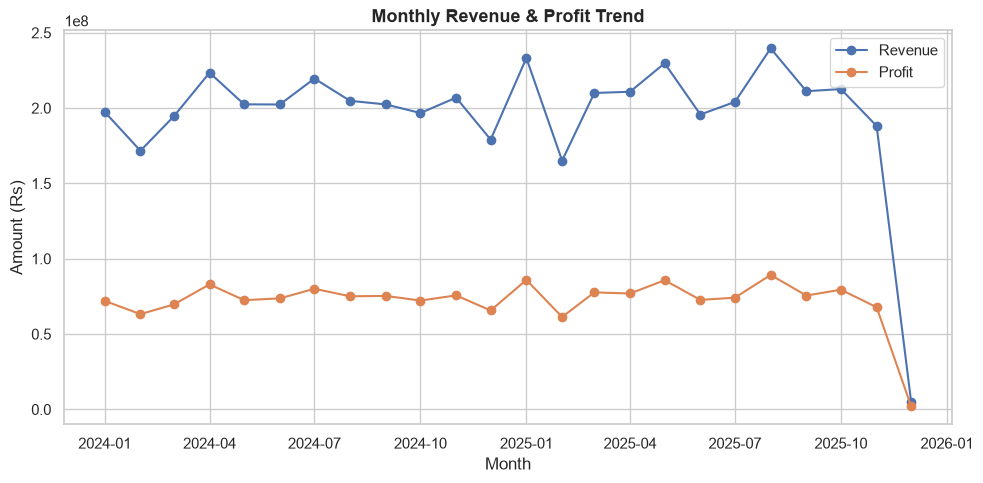

In [17]:
# Monthly revenue & profit trend.
monthly = (sales.dropna(subset=["Order_Month"])
           .groupby("Order_Month")[["Revenue", "Profit"]].sum())

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["Revenue"], marker="o", label="Revenue")
ax.plot(monthly.index, monthly["Profit"], marker="o", label="Profit")
ax.set_title("Monthly Revenue & Profit Trend")
ax.set_xlabel("Month"); ax.set_ylabel("Amount (Rs)")
ax.legend()
plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\1974497661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index,


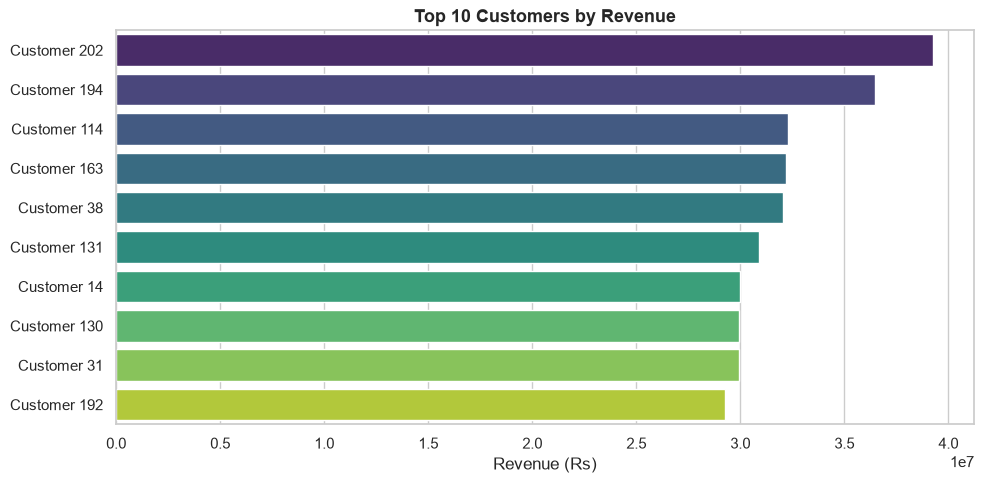

In [18]:
# Top 10 customers by revenue.
top_customers = (sales.groupby("Company_Name")["Revenue"].sum()
                 .sort_values(ascending=False).head(10))

fig, ax = plt.subplots()
sns.barplot(x=top_customers.values, y=top_customers.index,
            palette=PALETTE, ax=ax)
ax.set_title("Top 10 Customers by Revenue")
ax.set_xlabel("Revenue (Rs)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\3219876661.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_rev.index, y=country_rev.values, palette=PALETTE, ax=ax)


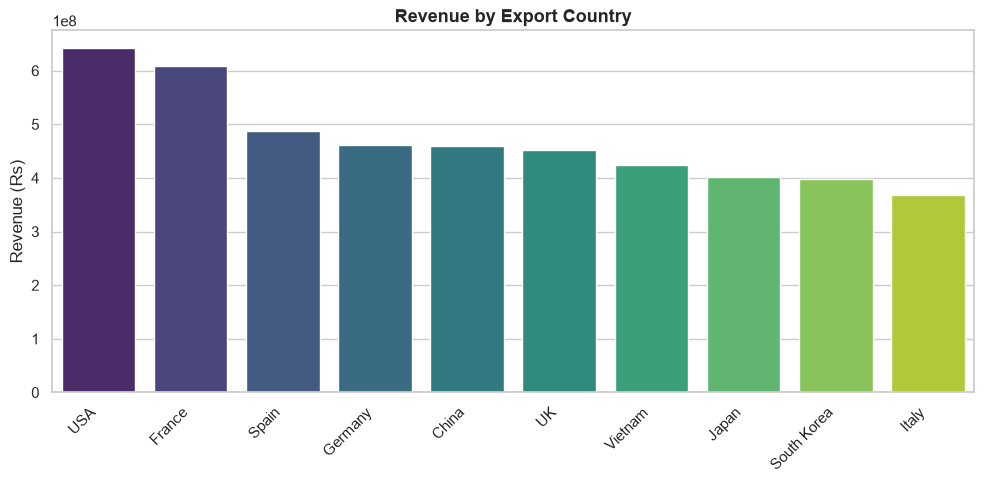

Revenue share (%):
Country
USA           13.70
France        13.00
Spain         10.40
Germany        9.80
China          9.80
UK             9.60
Vietnam        9.00
Japan          8.50
South Korea    8.50
Italy          7.80
Name: Revenue, dtype: float64


In [19]:
# Revenue by export country with share of total.
country_rev = (sales.groupby("Country")["Revenue"].sum()
               .sort_values(ascending=False))
country_share = (country_rev / country_rev.sum() * 100).round(1)

fig, ax = plt.subplots()
sns.barplot(x=country_rev.index, y=country_rev.values, palette=PALETTE, ax=ax)
ax.set_title("Revenue by Export Country")
ax.set_xlabel(""); ax.set_ylabel("Revenue (Rs)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

print("Revenue share (%):")
print(country_share)

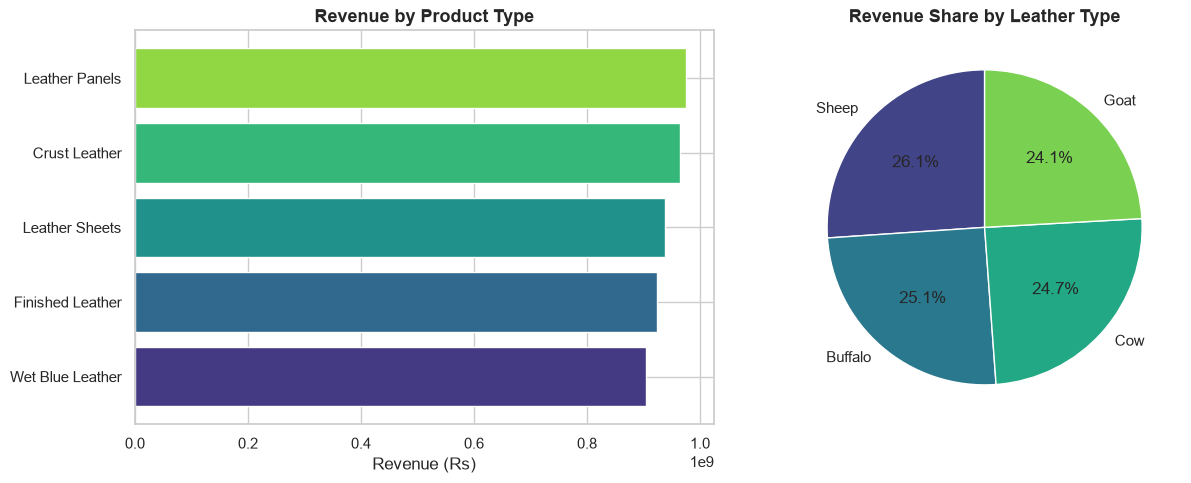

In [20]:
# Revenue by product type and leather type.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prod_rev = sales.groupby("Product_Type")["Revenue"].sum().sort_values()
axes[0].barh(prod_rev.index, prod_rev.values, color=sns.color_palette(PALETTE, len(prod_rev)))
axes[0].set_title("Revenue by Product Type")
axes[0].set_xlabel("Revenue (Rs)")

leather_rev = sales.groupby("Leather_Type")["Revenue"].sum().sort_values(ascending=False)
axes[1].pie(leather_rev.values, labels=leather_rev.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette(PALETTE, len(leather_rev)))
axes[1].set_title("Revenue Share by Leather Type")

plt.tight_layout(); plt.show()

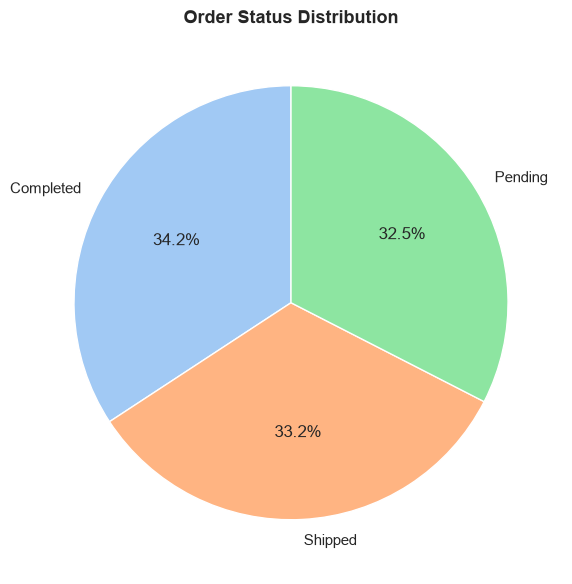

In [21]:
# Order status breakdown.
status = orders["Order_Status"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(status.values, labels=status.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("pastel", len(status)))
ax.set_title("Order Status Distribution")
plt.tight_layout(); plt.show()

### 5.2 Production

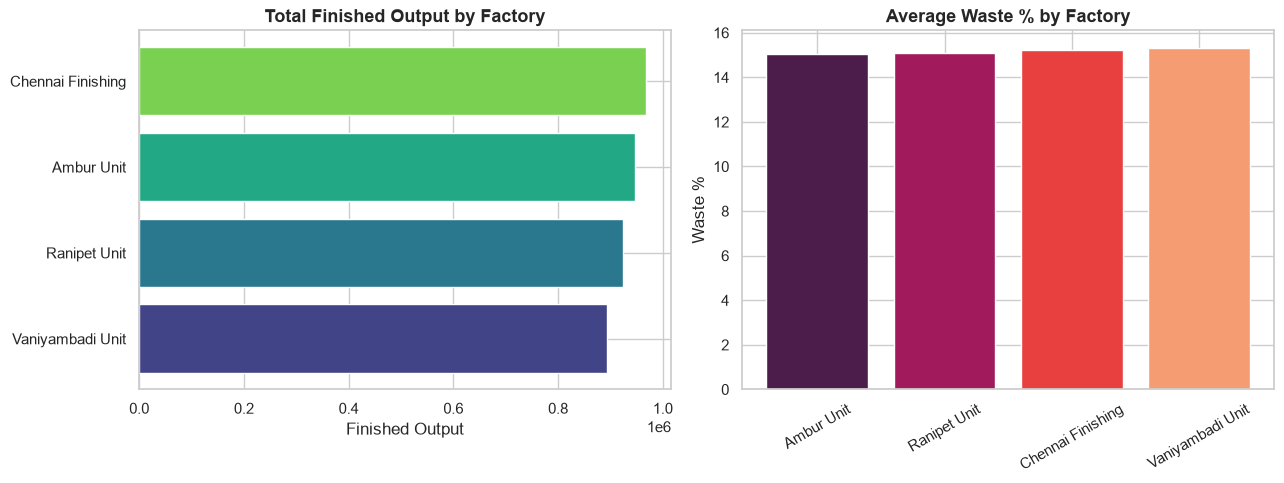

In [22]:
# Finished output and average waste by factory.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

output_by_factory = production.groupby("Factory_ID")["Finished_Output"].sum().sort_values()
axes[0].barh(output_by_factory.index, output_by_factory.values,
             color=sns.color_palette(PALETTE, len(output_by_factory)))
axes[0].set_title("Total Finished Output by Factory")
axes[0].set_xlabel("Finished Output")

waste_by_factory = production.groupby("Factory_ID")["Waste_Percentage"].mean().sort_values()
axes[1].bar(waste_by_factory.index, waste_by_factory.values,
            color=sns.color_palette("rocket", len(waste_by_factory)))
axes[1].set_title("Average Waste % by Factory")
axes[1].set_ylabel("Waste %")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\1425930090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=production, x="Factory_ID", y="Waste_Percentage",


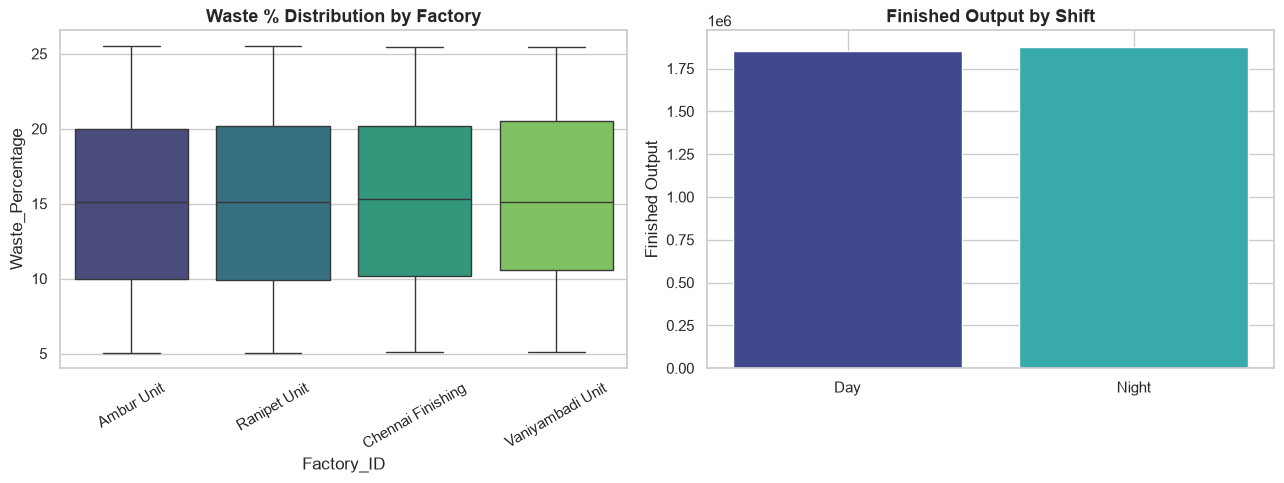

In [23]:
# Waste distribution by factory (box plot) and output by shift.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=production, x="Factory_ID", y="Waste_Percentage",
            palette=PALETTE, ax=axes[0])
axes[0].set_title("Waste % Distribution by Factory")
axes[0].tick_params(axis="x", rotation=30)

output_by_shift = production.groupby("Shift")["Finished_Output"].sum()
axes[1].bar(output_by_shift.index, output_by_shift.values,
            color=sns.color_palette("mako", len(output_by_shift)))
axes[1].set_title("Finished Output by Shift")
axes[1].set_ylabel("Finished Output")

plt.tight_layout(); plt.show()

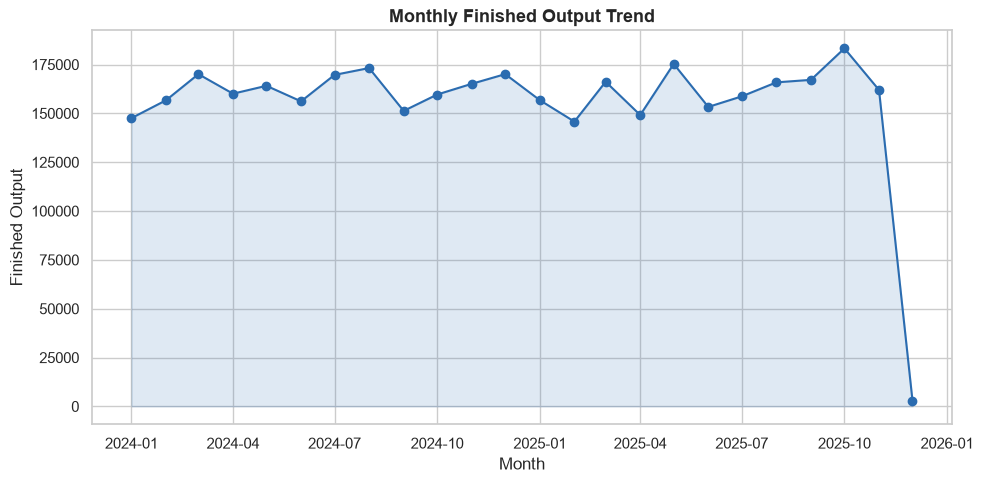

In [24]:
# Monthly production trend.
monthly_prod = production.groupby("Production_Month")["Finished_Output"].sum()
fig, ax = plt.subplots()
ax.plot(monthly_prod.index, monthly_prod.values, marker="o", color=ACCENT)
ax.fill_between(monthly_prod.index, monthly_prod.values, alpha=0.15, color=ACCENT)
ax.set_title("Monthly Finished Output Trend")
ax.set_xlabel("Month"); ax.set_ylabel("Finished Output")
plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\2041789183.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=util.values, y=util.index, palette=PALETTE, ax=ax)


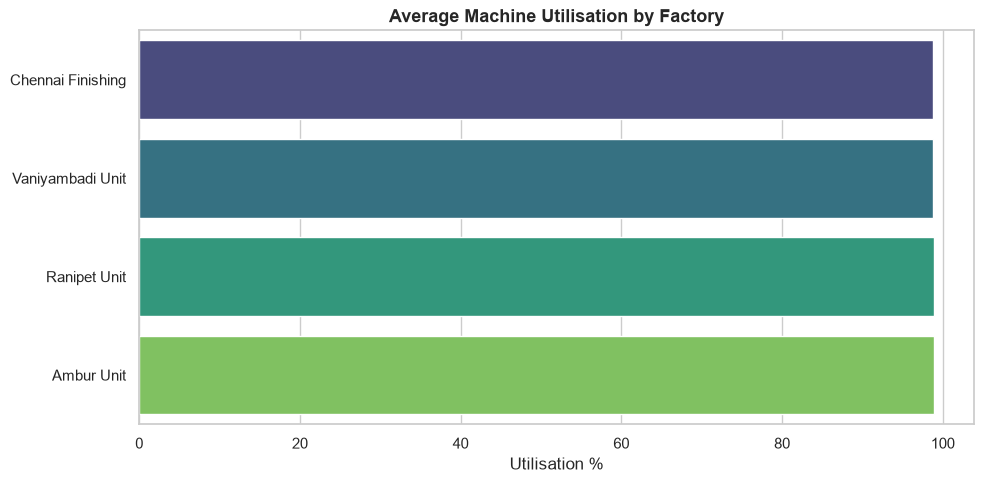

In [25]:
# Machine utilisation by factory.
util = machines.groupby("Factory_ID")["Utilization_Pct"].mean().sort_values()
fig, ax = plt.subplots()
sns.barplot(x=util.values, y=util.index, palette=PALETTE, ax=ax)
ax.set_title("Average Machine Utilisation by Factory")
ax.set_xlabel("Utilisation %"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### 5.3 Quality

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\2261068583.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade.index, y=grade.values, palette=PALETTE, ax=axes[0])


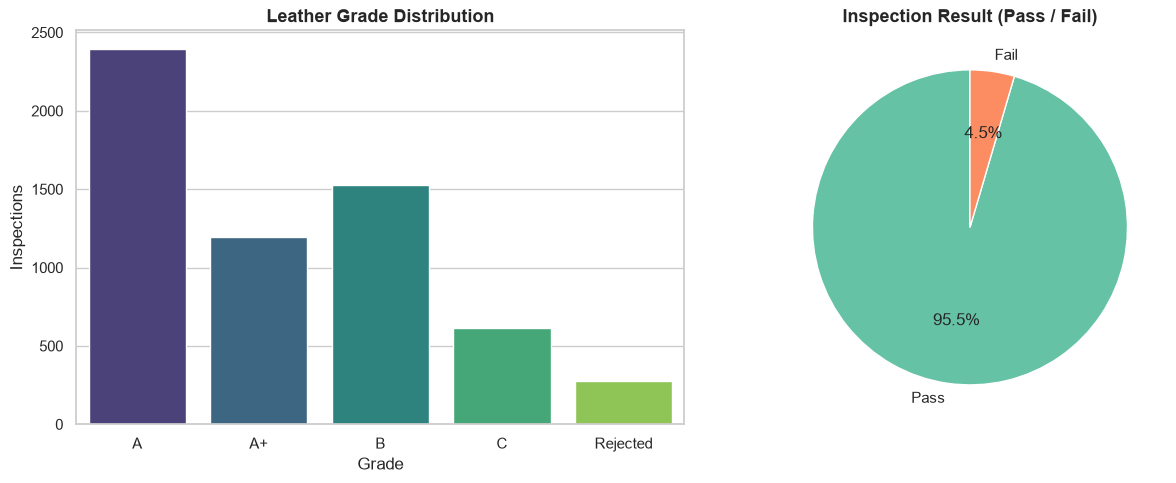

Overall quality pass rate: 95.5%


In [26]:
# Leather grade distribution and pass/fail split.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

grade = quality["Leather_Grade"].value_counts().sort_index()
sns.barplot(x=grade.index, y=grade.values, palette=PALETTE, ax=axes[0])
axes[0].set_title("Leather Grade Distribution")
axes[0].set_xlabel("Grade"); axes[0].set_ylabel("Inspections")

result = quality["Inspection_Result"].value_counts()
axes[1].pie(result.values, labels=result.index, autopct="%1.1f%%",
            startangle=90, colors=sns.color_palette("Set2", len(result)))
axes[1].set_title("Inspection Result (Pass / Fail)")

plt.tight_layout(); plt.show()

pass_rate = quality["Is_Pass"].mean() * 100
print(f"Overall quality pass rate: {pass_rate:.1f}%")

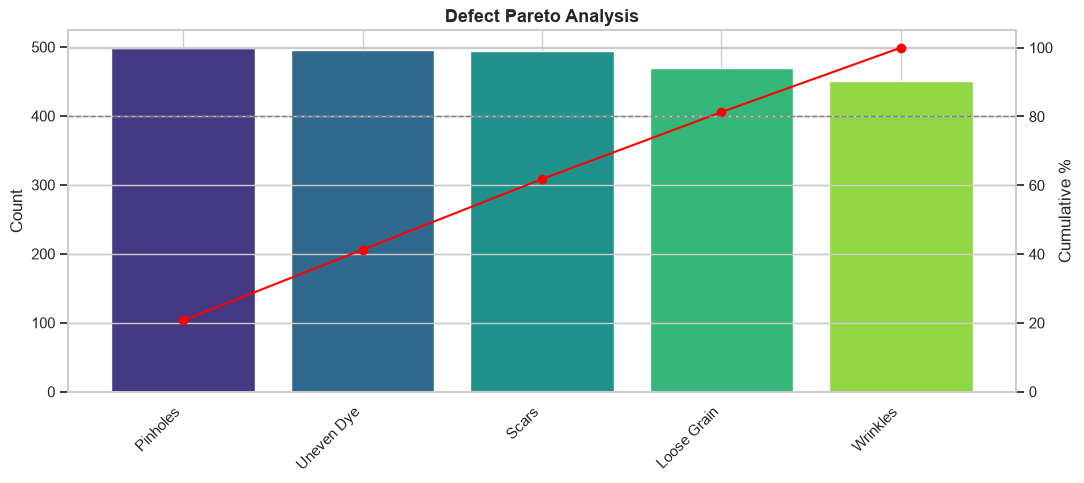

In [27]:
# Defect Pareto chart (which few defects cause most problems).
defects = quality.loc[quality["Defects"].str.lower() != "no defect", "Defects"]
defect_counts = defects.value_counts()
cum_pct = defect_counts.cumsum() / defect_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(defect_counts.index, defect_counts.values,
        color=sns.color_palette(PALETTE, len(defect_counts)))
ax1.set_ylabel("Count"); ax1.set_title("Defect Pareto Analysis")
ax1.tick_params(axis="x", rotation=45)
for label in ax1.get_xticklabels():
    label.set_ha("right")

ax2 = ax1.twinx()
ax2.plot(defect_counts.index, cum_pct.values, color="red", marker="o")
ax2.axhline(80, color="grey", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative %"); ax2.set_ylim(0, 105)

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\3517487520.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=quality, x="Leather_Grade", y="Color_Consistency",


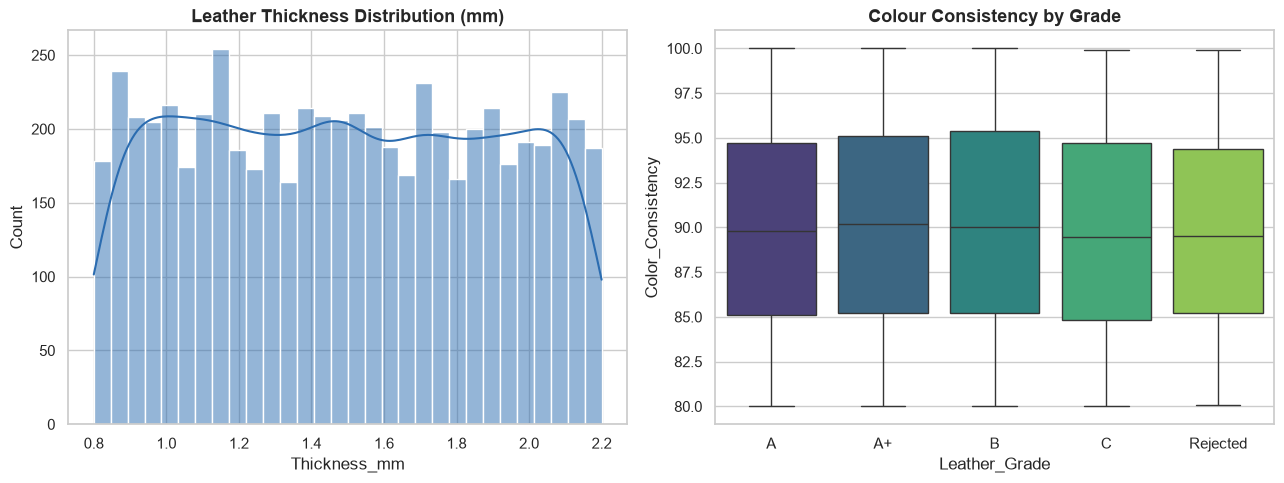

In [28]:
# Thickness distribution and colour consistency by grade.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(quality["Thickness_mm"], bins=30, kde=True, color=ACCENT, ax=axes[0])
axes[0].set_title("Leather Thickness Distribution (mm)")

sns.boxplot(data=quality, x="Leather_Grade", y="Color_Consistency",
            palette=PALETTE, ax=axes[1], order=sorted(quality["Leather_Grade"].unique()))
axes[1].set_title("Colour Consistency by Grade")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\2920529694.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sup, x="Average_Quality", y="Supplier_Name",


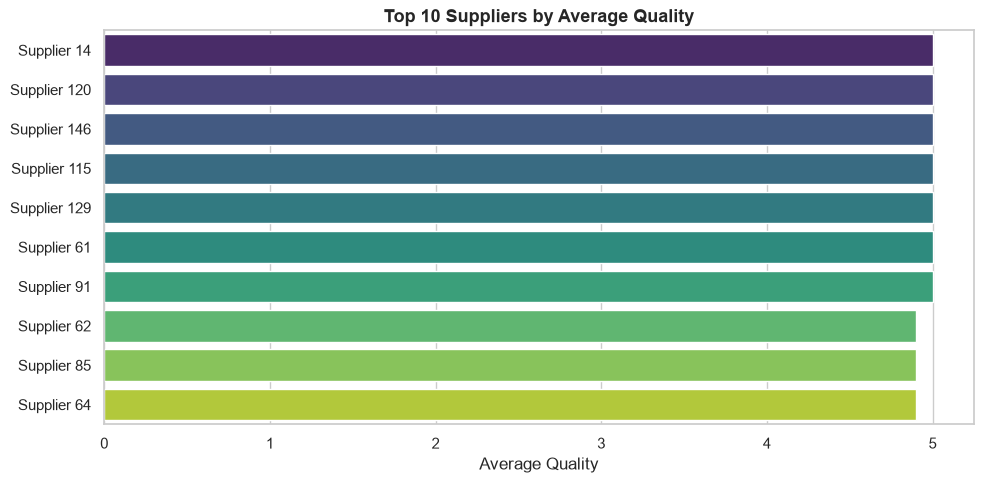

In [29]:
# Supplier quality ranking (top 10 by average quality).
sup = suppliers.sort_values("Average_Quality", ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=sup, x="Average_Quality", y="Supplier_Name",
            palette=PALETTE, ax=ax)
ax.set_title("Top 10 Suppliers by Average Quality")
ax.set_xlabel("Average Quality"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### 5.4 Inventory

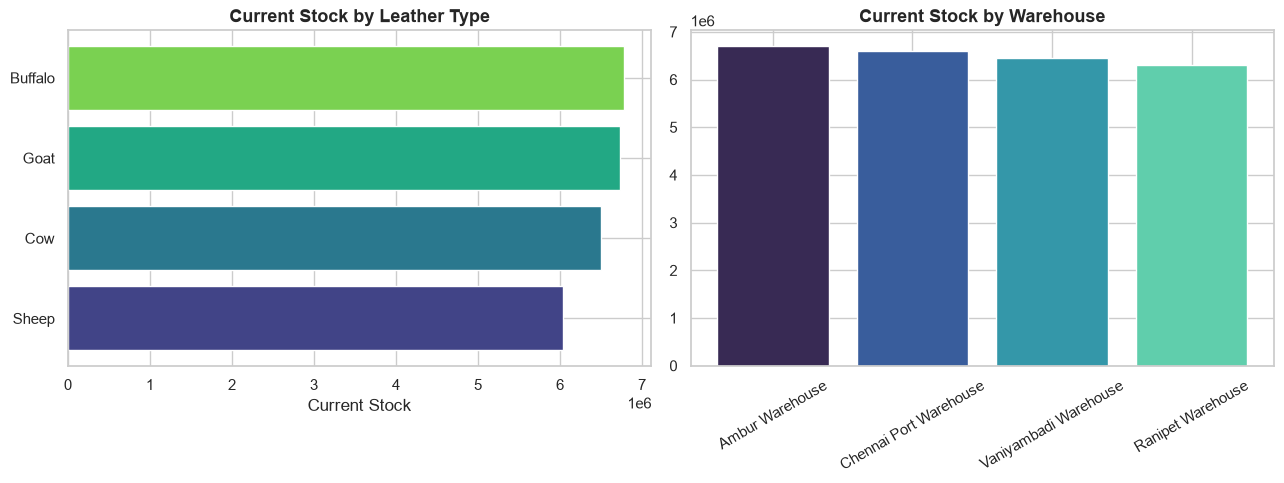

In [30]:
# Current stock by leather type and by warehouse.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stock_type = inventory.groupby("Leather_Type")["Current_Stock"].sum().sort_values()
axes[0].barh(stock_type.index, stock_type.values,
             color=sns.color_palette(PALETTE, len(stock_type)))
axes[0].set_title("Current Stock by Leather Type")
axes[0].set_xlabel("Current Stock")

stock_wh = inventory.groupby("Warehouse")["Current_Stock"].sum().sort_values(ascending=False)
axes[1].bar(stock_wh.index, stock_wh.values,
            color=sns.color_palette("mako", len(stock_wh)))
axes[1].set_title("Current Stock by Warehouse")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

Bins currently below reorder level: 279 of 5000


C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\2386001057.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reorder.index, y=reorder.values, palette="rocket", ax=ax)


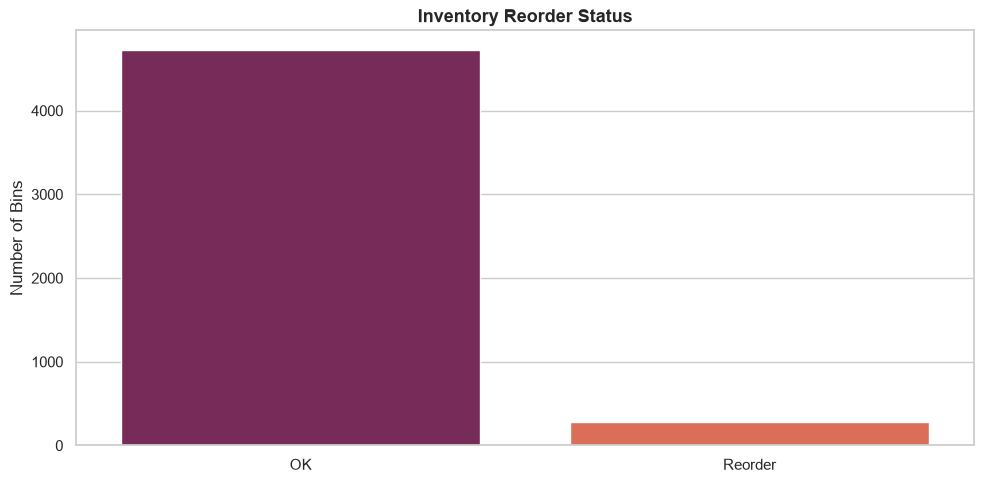

In [31]:
# Reorder status and count of bins below the minimum level.
below = int(inventory["Below_Reorder"].sum())
print(f"Bins currently below reorder level: {below} of {len(inventory)}")

reorder = inventory["Reorder_Status"].value_counts()
fig, ax = plt.subplots()
sns.barplot(x=reorder.index, y=reorder.values, palette="rocket", ax=ax)
ax.set_title("Inventory Reorder Status")
ax.set_xlabel(""); ax.set_ylabel("Number of Bins")
plt.tight_layout(); plt.show()

### 5.5 Shipment & Logistics

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\2696510674.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sstatus.index, y=sstatus.values, palette=PALETTE, ax=axes[1])


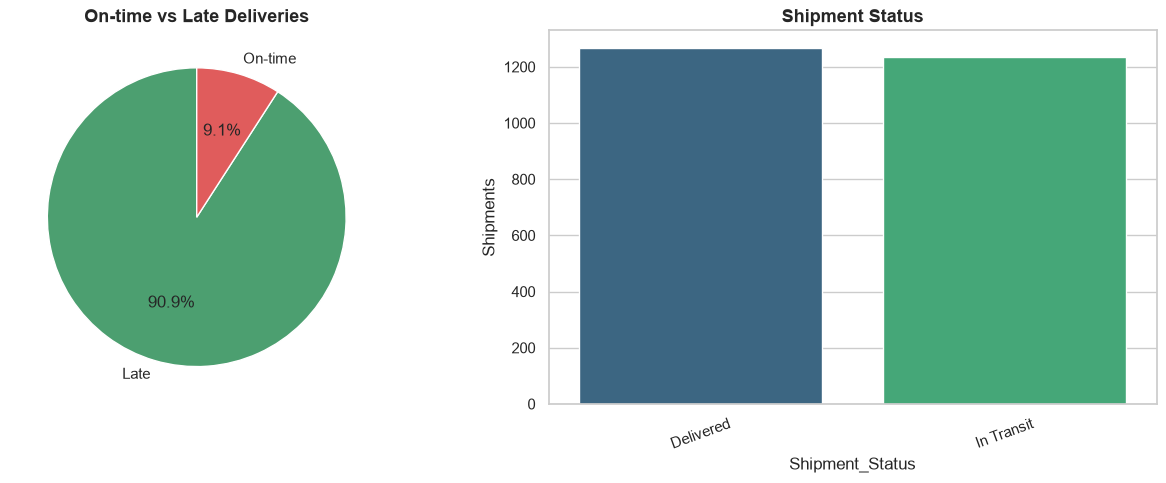

On-time delivery rate: 9.1%
Average delay (all shipments): 5.1 days


In [32]:
# On-time vs late and shipment status.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

late_split = shipment["Is_Late"].map({True: "Late", False: "On-time"}).value_counts()
axes[0].pie(late_split.values, labels=late_split.index, autopct="%1.1f%%",
            startangle=90, colors=["#4c9f70", "#e05c5c"])
axes[0].set_title("On-time vs Late Deliveries")

sstatus = shipment["Shipment_Status"].value_counts()
sns.barplot(x=sstatus.index, y=sstatus.values, palette=PALETTE, ax=axes[1])
axes[1].set_title("Shipment Status")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylabel("Shipments")

plt.tight_layout(); plt.show()

print(f"On-time delivery rate: {(~shipment['Is_Late']).mean()*100:.1f}%")
print(f"Average delay (all shipments): {shipment['Delay_Days'].mean():.1f} days")

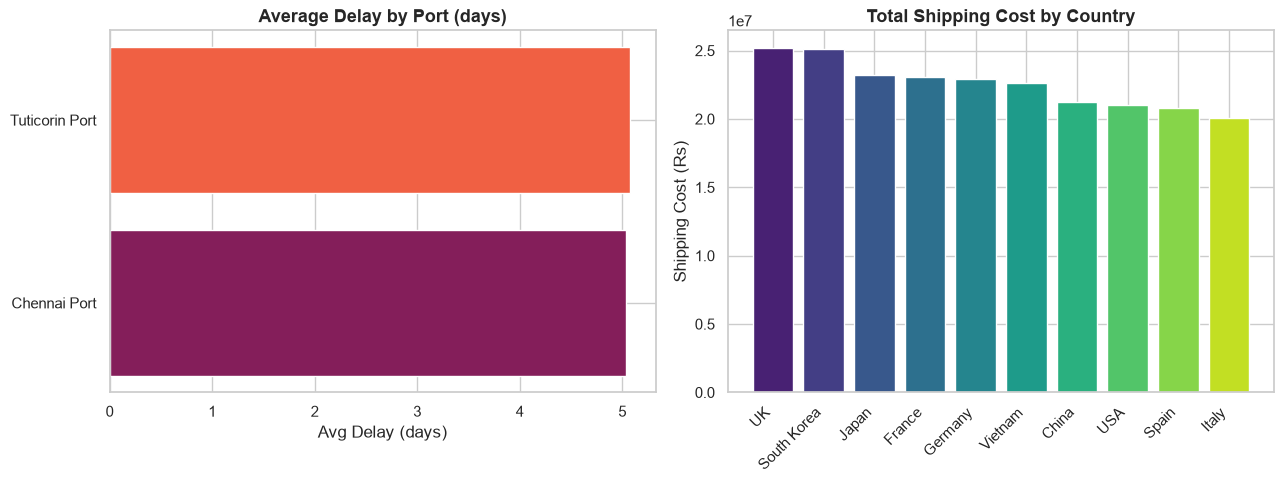

In [33]:
# Average delay by port and shipping cost by destination country.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

delay_port = shipment.groupby("Port")["Delay_Days"].mean().sort_values()
axes[0].barh(delay_port.index, delay_port.values,
             color=sns.color_palette("rocket", len(delay_port)))
axes[0].set_title("Average Delay by Port (days)")
axes[0].set_xlabel("Avg Delay (days)")

cost_country = shipment.groupby("Destination_Country")["Shipping_Cost"].sum().sort_values(ascending=False)
axes[1].bar(cost_country.index, cost_country.values,
            color=sns.color_palette(PALETTE, len(cost_country)))
axes[1].set_title("Total Shipping Cost by Country")
axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")
axes[1].set_ylabel("Shipping Cost (Rs)")

plt.tight_layout(); plt.show()

### 5.6 Finance

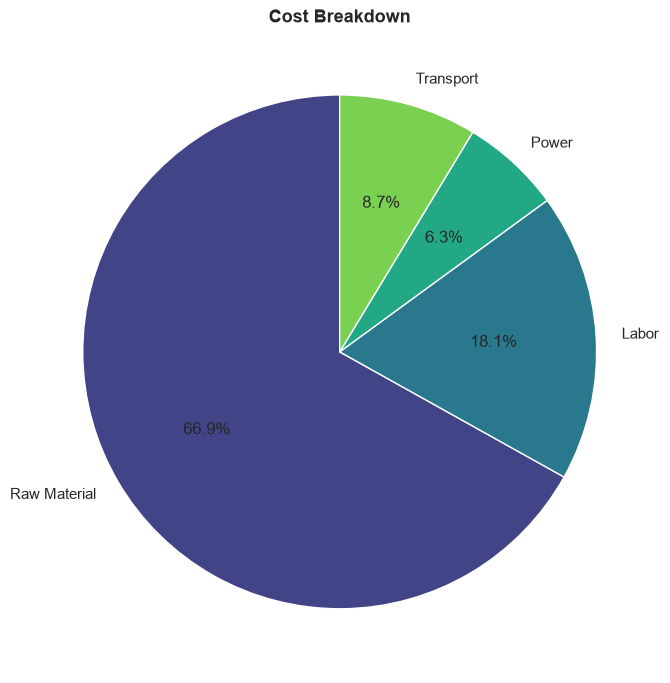

In [34]:
# Cost breakdown across the business.
cost_totals = finance[["Raw_Material_Cost", "Labor_Cost",
                       "Power_Cost", "Transport_Cost"]].sum()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(cost_totals.values,
       labels=["Raw Material", "Labor", "Power", "Transport"],
       autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette(PALETTE, 4))
ax.set_title("Cost Breakdown")
plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\4285403458.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pay.index, y=pay.values, palette="Set2", ax=axes[1])


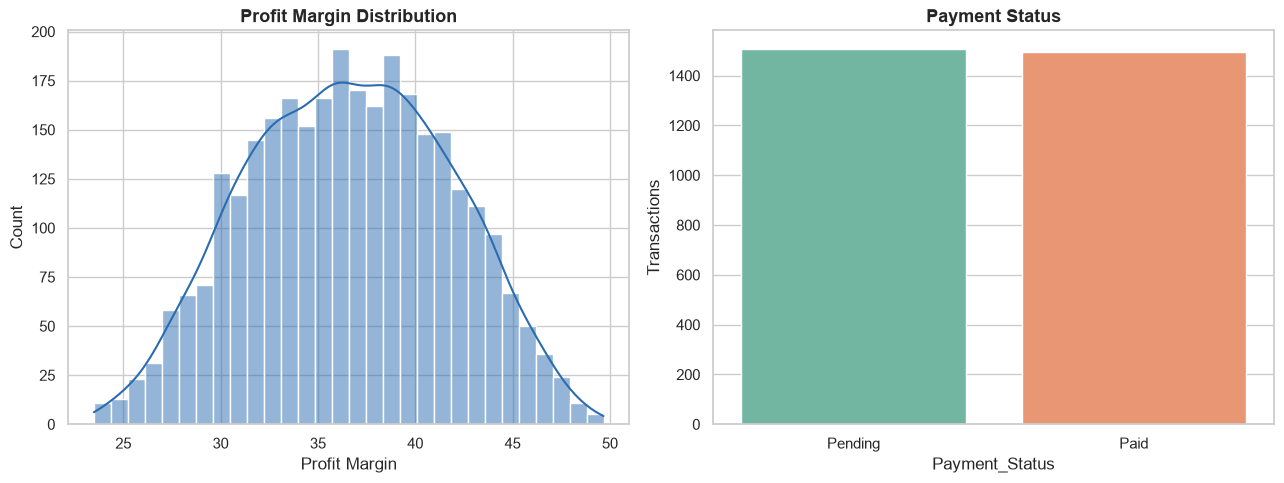

In [35]:
# Profit margin distribution and payment status.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(finance["Profit_Margin"], bins=30, kde=True, color=ACCENT, ax=axes[0])
axes[0].set_title("Profit Margin Distribution")
axes[0].set_xlabel("Profit Margin")

pay = finance["Payment_Status"].value_counts()
sns.barplot(x=pay.index, y=pay.values, palette="Set2", ax=axes[1])
axes[1].set_title("Payment Status")
axes[1].set_ylabel("Transactions")

plt.tight_layout(); plt.show()

### 5.7 Workforce

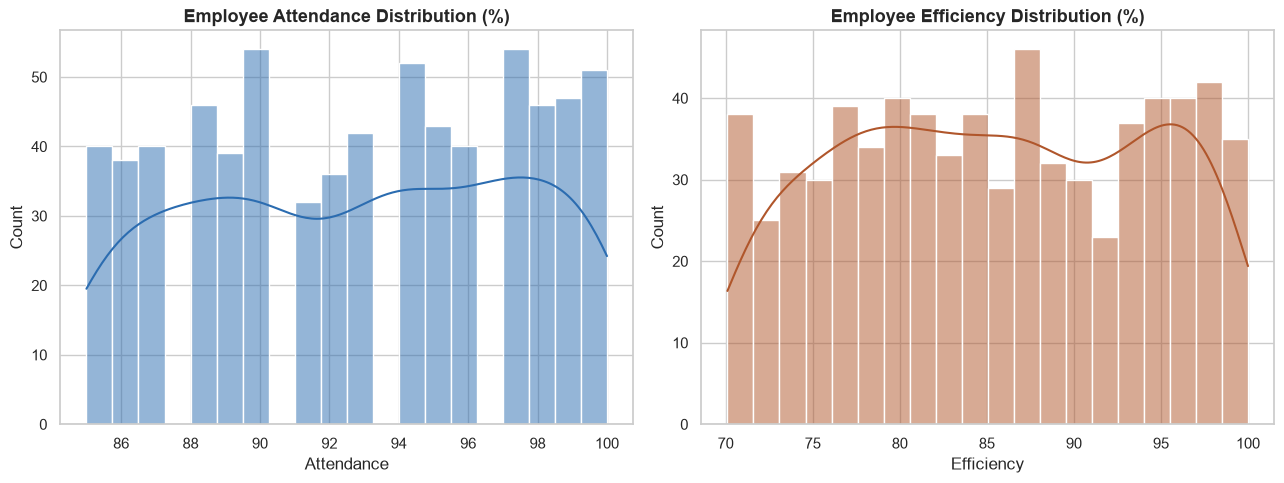

In [36]:
# Attendance and efficiency distributions.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(employees["Attendance"], bins=20, kde=True, color=ACCENT, ax=axes[0])
axes[0].set_title("Employee Attendance Distribution (%)")
sns.histplot(employees["Efficiency"], bins=20, kde=True, color="#b0562b", ax=axes[1])
axes[1].set_title("Employee Efficiency Distribution (%)")
plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_11052\2701737284.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employees, x="Department", y="Salary", palette=PALETTE, ax=axes[1])


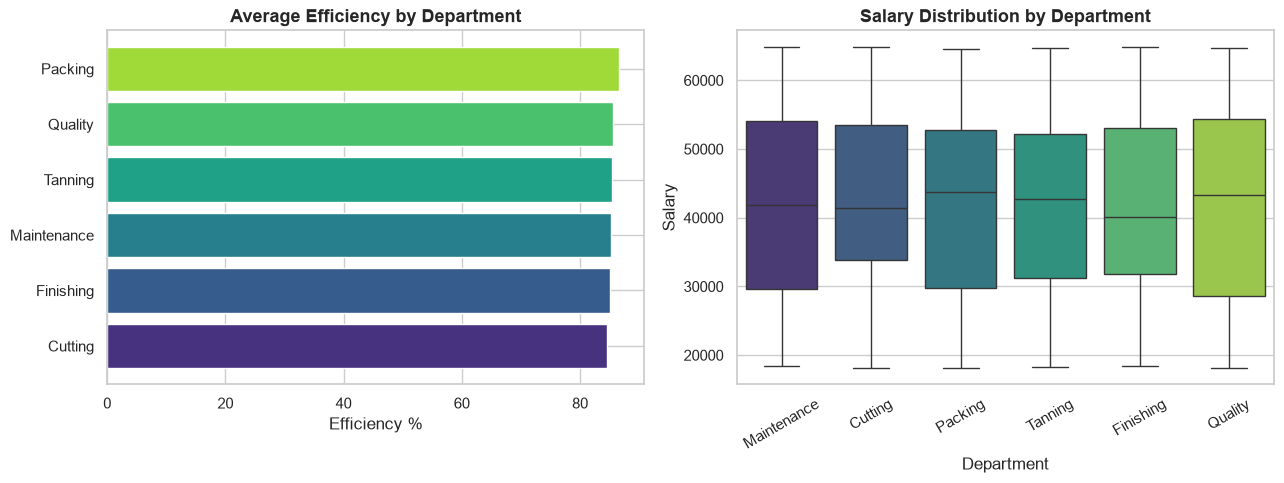

In [37]:
# Department efficiency, salary spread and experience vs efficiency.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dept_eff = employees.groupby("Department")["Efficiency"].mean().sort_values()
axes[0].barh(dept_eff.index, dept_eff.values,
             color=sns.color_palette(PALETTE, len(dept_eff)))
axes[0].set_title("Average Efficiency by Department")
axes[0].set_xlabel("Efficiency %")

sns.boxplot(data=employees, x="Department", y="Salary", palette=PALETTE, ax=axes[1])
axes[1].set_title("Salary Distribution by Department")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

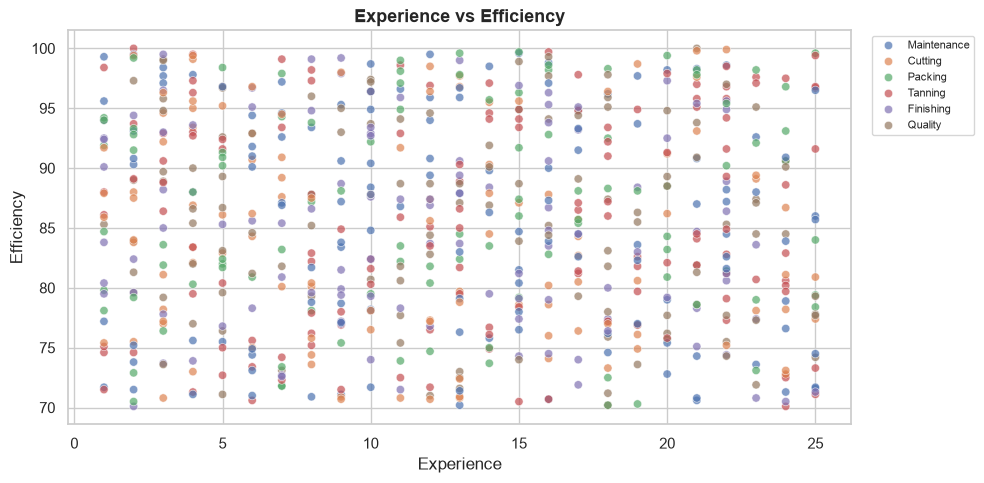

In [38]:
# Experience vs efficiency relationship.
fig, ax = plt.subplots()
sns.scatterplot(data=employees, x="Experience", y="Efficiency",
                hue="Department", alpha=0.7, ax=ax)
ax.set_title("Experience vs Efficiency")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

### 5.8 Correlation Analysis

A correlation heatmap of the financial measures helps confirm expected
relationships (e.g. revenue vs profit) and spot anything unusual.

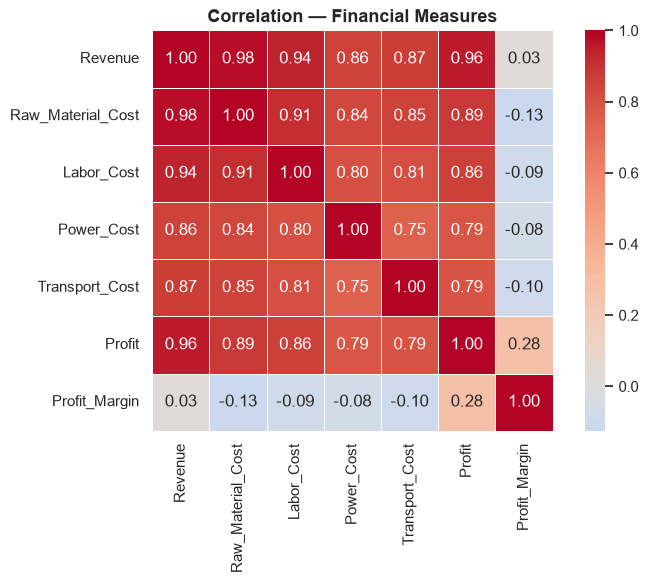

In [39]:
num_cols = ["Revenue", "Raw_Material_Cost", "Labor_Cost", "Power_Cost",
            "Transport_Cost", "Profit", "Profit_Margin"]
corr = finance[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation — Financial Measures")
plt.tight_layout(); plt.show()

## 6. Key Insights

> The specific numbers below are computed in the next cell so they always match
> the data.

In [40]:
# Programmatically generate the headline findings.
top_country = country_rev.index[0]
top_country_share = country_share.iloc[0]
top_customer = top_customers.index[0]
best_factory = production.groupby("Factory_ID")["Waste_Percentage"].mean().idxmin()
worst_delay_port = shipment.groupby("Port")["Delay_Days"].mean().idxmax()
biggest_cost = cost_totals.idxmax()

print("KEY INSIGHTS")
print("=" * 55)
print(f"1. Total revenue is Rs {total_revenue:,.0f} at a {margin:.1f}% margin.")
print(f"2. {top_country} is the largest market ({top_country_share:.1f}% of revenue).")
print(f"3. {top_customer} is the single biggest customer by revenue.")
print(f"4. {best_factory} runs the lowest average waste %.")
print(f"5. Overall quality pass rate is {pass_rate:.1f}%.")
print(f"6. On-time delivery rate is {(~shipment['Is_Late']).mean()*100:.1f}%; "
      f"{worst_delay_port} has the worst average delay.")
print(f"7. {biggest_cost.replace('_', ' ')} is the largest cost component.")
print(f"8. {below} inventory bins are below their reorder level.")

KEY INSIGHTS
1. Total revenue is Rs 4,706,028,842 at a 36.7% margin.
2. USA is the largest market (13.7% of revenue).
3. Customer 202 is the single biggest customer by revenue.
4. Ambur Unit runs the lowest average waste %.
5. Overall quality pass rate is 95.5%.
6. On-time delivery rate is 9.1%; Tuticorin Port has the worst average delay.
7. Raw Material Cost is the largest cost component.
8. 279 inventory bins are below their reorder level.


## 7. Conclusion & Recommendations

**Conclusion.** The business is profitable and export-diversified, but the
analysis highlights a few clear levers for improvement across production waste,
logistics reliability and inventory discipline.

**Recommendations.**

1. **Reduce waste at the weaker factories** — bring higher-waste units closer
   to the best-performing factory's waste level.
2. **Tackle logistics delays** — investigate the worst-performing ports and
   renegotiate or reroute where delays are systemic.
3. **Enforce reorder discipline** — automate alerts for bins that fall below the
   minimum level to avoid stock-outs.
4. **Protect quality** — focus corrective action on the top defects identified in
   the Pareto chart (the vital few that drive ~80% of rejections).
5. **Grow the strongest markets** — deepen relationships with the top revenue
   country and top customers while diversifying to reduce concentration risk.

## 8. Future Work

- Add **time-series forecasting** (e.g. revenue / production) with seasonality.
- Build a **predictive model** for shipment delay or quality pass/fail.
- Combine this notebook with an interactive dashboard for business users.

---
*Prepared as a Data Analytics internship project for A.S. Solutions.*